# Autoencoder

#### 1. Import Required Libraries

In [22]:
from __future__ import annotations
import os, glob, math, random
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kneed import KneeLocator

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

#### Utilities

In [2]:
def set_seed(seed: int = 42) -> None:
    """Set all relevant random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def device() -> str:
    """Return 'cuda' if available, otherwise 'cpu'."""
    return "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)
print("Device:", device())


Device: cpu


#### 2. Load and Explore the Dataset

In [3]:
CSV_PATTERN = "/home/falih/Mastercode/Bundesliga_2023_2024/formations/labled/data_understanding/cleaned_data_window_global.csv"

def load_data(csv_pattern: str) -> pd.DataFrame:
    """
    Load all CSV files matching the pattern and concatenate them into a single DataFrame.
    """
    files = glob.glob(csv_pattern)
    if not files:
        raise FileNotFoundError(f"No file found for pattern: {csv_pattern}")
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    return df

df = load_data(CSV_PATTERN)
print("Loaded rows:", len(df))
print("Teams:", sorted(df["team_code"].dropna().unique().tolist())[:20])

Loaded rows: 488510
Teams: ['B04', 'BMG', 'BOC', 'BVB', 'FCA', 'FCB', 'FCU', 'HDH', 'KOE', 'M05', 'RBL', 'SCF', 'SGE', 'SVD', 'SVW', 'TSG', 'VFB', 'WOB']


#### 3. Build X (one row per (match_id, team_code, window_global))

In [ ]:
PLAYER_FEATS = ["x_norm_mean", "y_norm_mean", "x_norm_std", "y_norm_std"]
GROUP_COLS   = ["match_id", "team_code", "window_global"]

def build_X(df: pd.DataFrame) -> Tuple[np.ndarray, pd.DataFrame]:
    """
    Build a fixed-length feature matrix X:
    - One row per unique (match_id, team_code, window_global)
    - Only windows with exactly 10 players are kept
    - Players are sorted spatially to get a consistent ordering
    """
    # Determine necessary columns
    need = set(PLAYER_FEATS + GROUP_COLS + ["player_name"])
    cols = [c for c in df.columns if c in need]
    df2 = df[cols].copy()

    rows, metas = [], []

    # Group by match, team, and global window
    for keys, g in df2.groupby(GROUP_COLS, sort=False):
        # Skip windows that do not contain exactly 10 players
        if len(g) != 10:
            continue

        # Sort players spatially to create a consistent 40-dim vector
        g_sorted = g.sort_values(["y_norm_mean", "x_norm_mean"], ascending=[False, True])

        # Flatten player features (10 players * 4 features = 40)
        rows.append(g_sorted[PLAYER_FEATS].to_numpy().reshape(-1))
        metas.append(keys)

    if not rows:
        raise ValueError("No valid windows with 10 outfield players were found.")

    # Stack rows into matrix X
    X = np.vstack(rows).astype("float32")
    meta = pd.DataFrame(metas, columns=GROUP_COLS)
    return X, meta

#### 4. Split by possession state

In [5]:
print(df["dominant_possession_team"].value_counts(dropna=False))

# Split into in-possession and out-of-possession subsets
df_in  = df[df["dominant_possession_team"] == "In_possession"].copy()
df_out = df[df["dominant_possession_team"] == "Out_of_possession"].copy()

print("In_possession windows:", df_in["window_global"].nunique())
print("Out_of_possession windows:", df_out["window_global"].nunique())

def build_X_possession(df_part: pd.DataFrame, label: str):
    """
    Convenience wrapper to build X and meta for a given possession subset.
    """
    X, meta = build_X(df_part)
    print(f"{label}: X shape = {X.shape}")
    return X, meta

X_in,  meta_in  = build_X_possession(df_in,  "In_possession")
X_out, meta_out = build_X_possession(df_out, "Out_of_possession")

dominant_possession_team
In_possession        245080
Out_of_possession    243430
Name: count, dtype: int64
In_possession windows: 24508
Out_of_possession windows: 24343
In_possession: X shape = (24508, 40)
Out_of_possession: X shape = (24343, 40)


#### 5. Autoencoder definition

In [6]:
class AE(nn.Module):
    """
    Simple fully-connected autoencoder with a bottleneck of dimension d_z.
    """
    def __init__(self, d_in: int = 40, d_z: int = 4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Linear(64, d_z)
        )
        self.dec = nn.Sequential(
            nn.Linear(d_z, 64),
            nn.ReLU(),
            nn.Linear(64, d_in)
        )

    def forward(self, x):
        z = self.enc(x)
        xhat = self.dec(z)
        return xhat, z


def fit_autoencoder(
    Xn: np.ndarray,
    d_z: int = 4,
    epochs: int = 30,
    batch_size: int = 256,
    lr: float = 1e-3,
    verbose: bool = True
) -> Tuple[nn.Module, np.ndarray, list]:
    """
    Train the autoencoder on normalized data Xn and return:
    - the trained model,
    - the latent representation Z,
    - the loss history per epoch.
    """
    dev = device()
    model = AE(d_in=Xn.shape[1], d_z=d_z).to(dev)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Create DataLoader
    ds = TensorDataset(torch.from_numpy(Xn.astype("float32")))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, pin_memory=(dev == "cuda"))

    history = []

    # Training loop
    model.train()
    for ep in range(epochs):
        loss_sum = 0.0
        for (xb,) in dl:
            xb = xb.to(dev)
            xhat, _ = model(xb)
            loss = loss_fn(xhat, xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            loss_sum += float(loss.item()) * xb.size(0)

        epoch_loss = loss_sum / len(ds)
        history.append(epoch_loss)

        if verbose:
            print(f"Epoch {ep+1:02d}  loss={epoch_loss:.6f}")

    # Compute latent space Z after training
    model.eval()
    with torch.no_grad():
        Z = model.enc(torch.from_numpy(Xn).to(dev)).cpu().numpy()

    return model, Z, history

#### 6. Train separate autoencoders

In [7]:
# Standardize features for both possession states
scaler_in  = StandardScaler()
Xn_in  = scaler_in.fit_transform(X_in).astype("float32")

scaler_out = StandardScaler()
Xn_out = scaler_out.fit_transform(X_out).astype("float32")

# Example for In_possession
model_in, Z_in, history_in = fit_autoencoder(Xn_in, d_z=4, epochs=60, batch_size=256, lr=1e-3)

# Example for Out_of_possession
model_out, Z_out, history_out = fit_autoencoder(Xn_out, d_z=4, epochs=60, batch_size=256, lr=1e-3)

Epoch 01  loss=0.805794
Epoch 02  loss=0.647084
Epoch 03  loss=0.628094
Epoch 04  loss=0.619811
Epoch 05  loss=0.613928
Epoch 06  loss=0.609355
Epoch 07  loss=0.606107
Epoch 08  loss=0.603636
Epoch 09  loss=0.601449
Epoch 10  loss=0.599360
Epoch 11  loss=0.597409
Epoch 12  loss=0.595725
Epoch 13  loss=0.594084
Epoch 14  loss=0.592597
Epoch 15  loss=0.591332
Epoch 16  loss=0.590210
Epoch 17  loss=0.589066
Epoch 18  loss=0.587951
Epoch 19  loss=0.587024
Epoch 20  loss=0.586046
Epoch 21  loss=0.585173
Epoch 22  loss=0.584321
Epoch 23  loss=0.583491
Epoch 24  loss=0.582527
Epoch 25  loss=0.581895
Epoch 26  loss=0.580992
Epoch 27  loss=0.580221
Epoch 28  loss=0.579325
Epoch 29  loss=0.578555
Epoch 30  loss=0.577947
Epoch 31  loss=0.577145
Epoch 32  loss=0.576583
Epoch 33  loss=0.575954
Epoch 34  loss=0.575283
Epoch 35  loss=0.574713
Epoch 36  loss=0.574032
Epoch 37  loss=0.573600
Epoch 38  loss=0.573151
Epoch 39  loss=0.572459
Epoch 40  loss=0.572046
Epoch 41  loss=0.571492
Epoch 42  loss=0

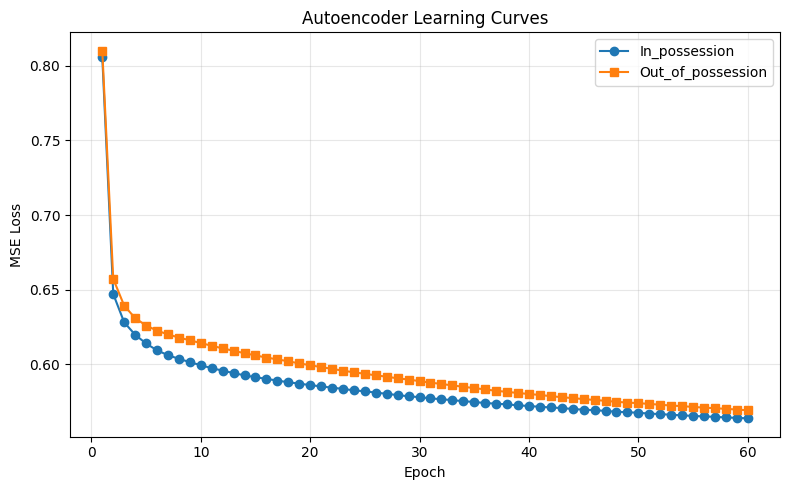

In [8]:
# Plot learning curves for both autoencoders
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history_in)+1), history_in, label="In_possession", marker='o')
plt.plot(range(1, len(history_out)+1), history_out, label="Out_of_possession", marker='s')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Learning Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 7. Elbow Methode with automatic knee detection

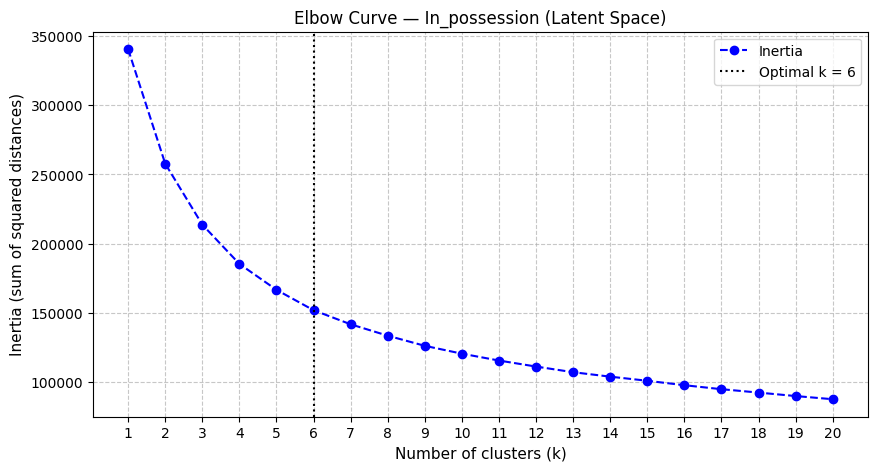

→ Optimal k according to Kneedle: 6


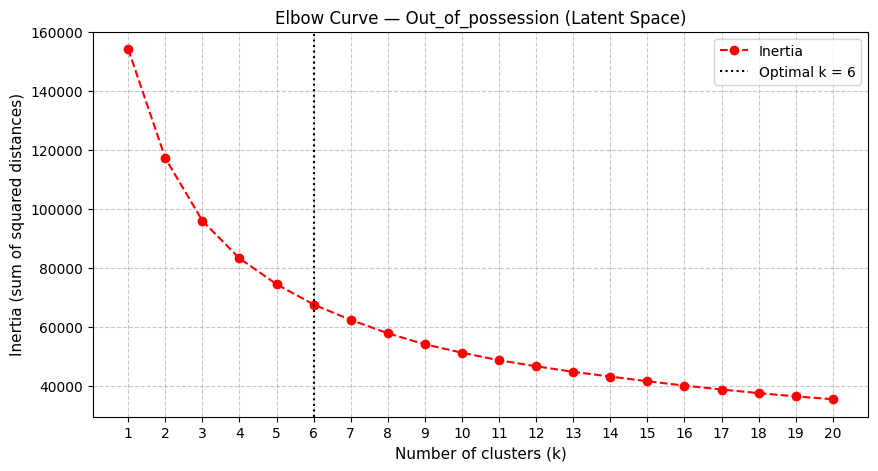

→ Optimal k according to Kneedle: 6


In [14]:
# Range of possible cluster numbers
k_range = range(1, 21)

def elbow_plot(Z, title, color):
    """
    Compute and visualize the Elbow curve (inertia vs. k) for given data Z.
    Additionally, the 'knee' (optimal k) is determined using the Kneedle algorithm.
    """
    inertia = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(Z)
        inertia.append(kmeans.inertia_)

    # Automatically detect the knee point
    kneedle = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
    optimal_k = kneedle.knee

    # Plot elbow curve
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, inertia, marker='o', linestyle='--', color=color, label='Inertia')
    if optimal_k:
        plt.axvline(x=optimal_k, color='black', linestyle=':', label=f'Optimal k = {optimal_k}')
    plt.title(title, fontsize=12)
    plt.xlabel("Number of clusters (k)", fontsize=11)
    plt.ylabel("Inertia (sum of squared distances)", fontsize=11)
    plt.xticks(k_range)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print(f"→ Optimal k according to Kneedle: {optimal_k}")

# Elbow for latent spaces (autoencoder output)
elbow_plot(Z_in,  "Elbow Curve — In_possession (Latent Space)",  "blue")
elbow_plot(Z_out, "Elbow Curve — Out_of_possession (Latent Space)", "red")

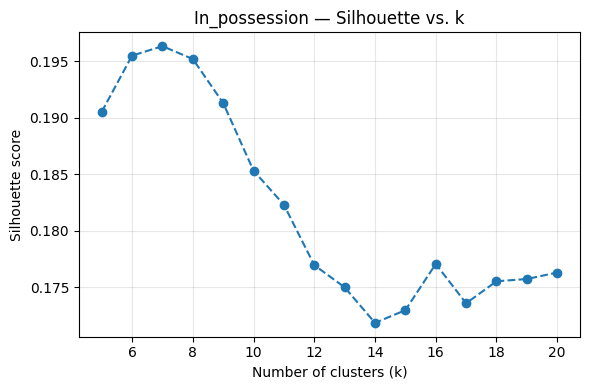

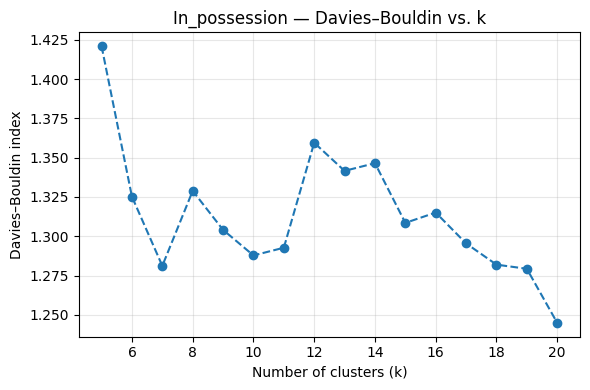

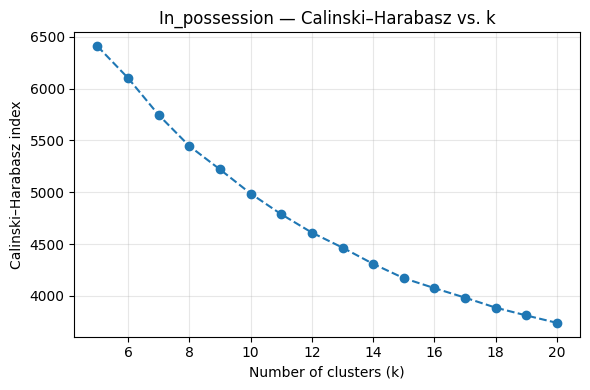

Best k by Silhouette:          k=7  (score=0.1963)
Best k by Calinski–Harabasz:   k=5 (score=6408.3564)
Best k by Davies–Bouldin (min):k=20 (score=1.2449)


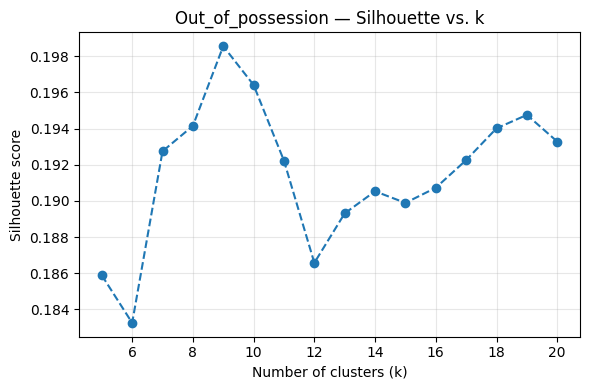

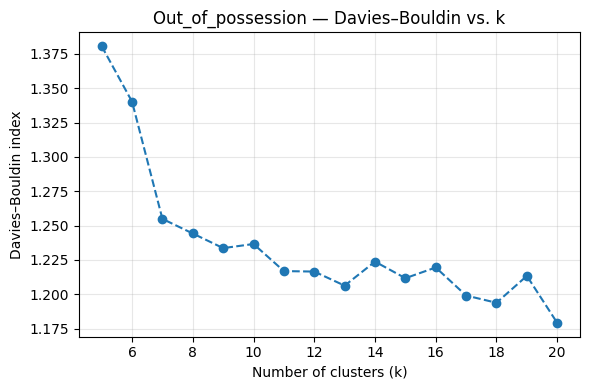

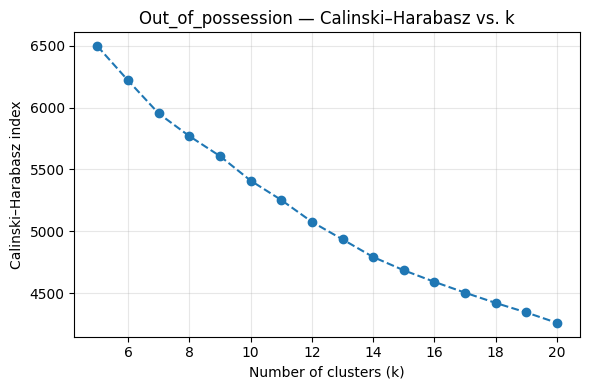

Best k by Silhouette:          k=9  (score=0.1986)
Best k by Calinski–Harabasz:   k=5 (score=6495.7056)
Best k by Davies–Bouldin (min):k=20 (score=1.1792)


In [ ]:
def clustering_metrics_vs_k_separate(Z, k_values, title_prefix=""):
    """
    Compute and plot clustering quality metrics (Silhouette, Davies–Bouldin, Calinski–Harabasz)
    for different numbers of clusters k.
    """
    results = []
    for k in k_values:
        if k < 2:
            continue
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Z)

        s  = silhouette_score(Z, labels)
        db = davies_bouldin_score(Z, labels)
        ch = calinski_harabasz_score(Z, labels)

        results.append((k, s, db, ch))

    if not results:
        print("No valid k values (need k >= 2).")
        return

    ks, ss, dbs, chs = zip(*results)

    # Plot 1: Silhouette
    plt.figure(figsize=(6,4))
    plt.plot(ks, ss, marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(f"{title_prefix} — Silhouette vs. k")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot 2: Davies–Bouldin
    plt.figure(figsize=(6,4))
    plt.plot(ks, dbs, marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Davies–Bouldin index")
    plt.title(f"{title_prefix} — Davies–Bouldin vs. k")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot 3: Calinski–Harabasz
    plt.figure(figsize=(6,4))
    plt.plot(ks, chs, marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Calinski–Harabasz index")
    plt.title(f"{title_prefix} — Calinski–Harabasz vs. k")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print best k according to each metric
    print(f"Best k by Silhouette:          k={ks[int(np.argmax(ss))]}  (score={max(ss):.4f})")
    print(f"Best k by Calinski–Harabasz:   k={ks[int(np.argmax(chs))]} (score={max(chs):.4f})")
    print(f"Best k by Davies–Bouldin (min):k={ks[int(np.argmin(dbs))]} (score={min(dbs):.4f})")

# Call for both possession states
clustering_metrics_vs_k_separate(Z_in,  range(5, 21), title_prefix="In_possession")
clustering_metrics_vs_k_separate(Z_out, range(5, 21), title_prefix="Out_of_possession")

#### 8. KMeans & PCA for both possession states

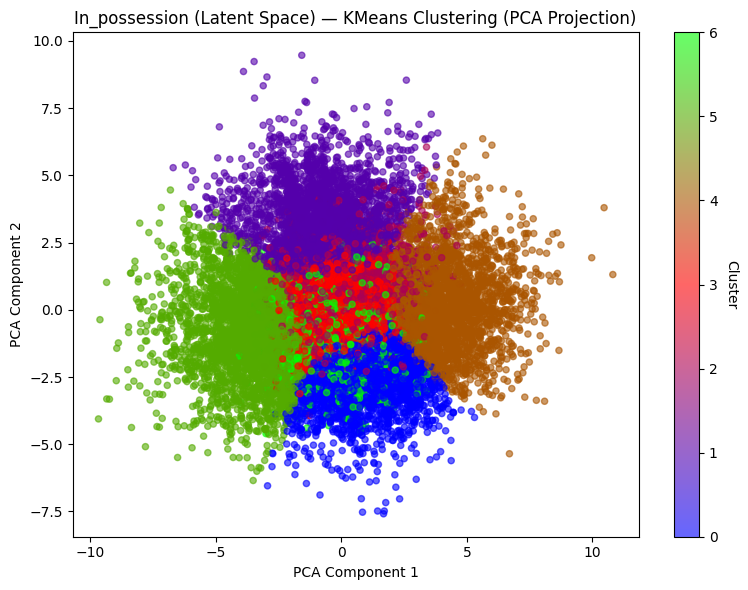

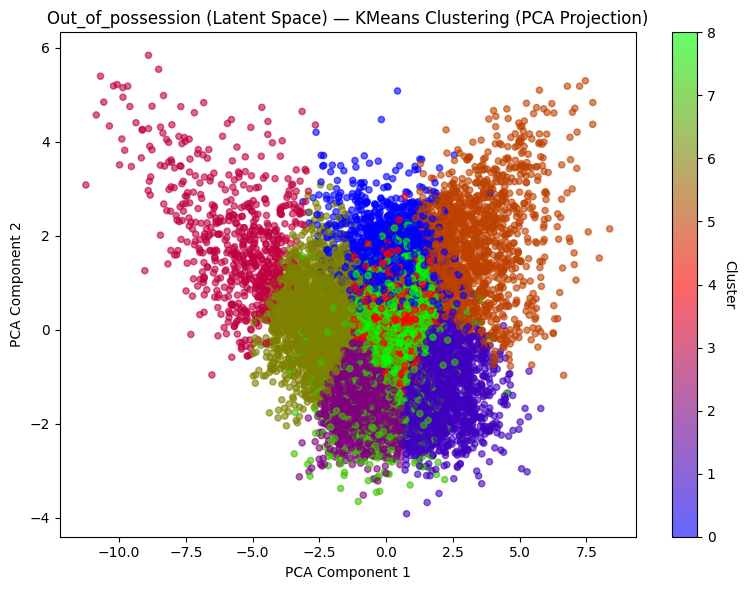

In [16]:
def cluster_and_plot(Z, meta, n_clusters, title_prefix):
    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Z)
    meta = meta.copy()
    meta["cluster"] = labels

    # PCA for 2D visualization
    pca = PCA(n_components=2, random_state=42)
    Z2 = pca.fit_transform(Z)

    # PCA scatter plot with color-coded clusters and colorbar
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        Z2[:, 0], Z2[:, 1],
        c=labels,
        cmap="brg",
        alpha=0.6,
        s=20
    )

    plt.title(f"{title_prefix} — KMeans Clustering (PCA Projection)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")

    # Colorbar showing cluster IDs
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

    return meta


# Apply on both possession states
meta_in_k  = cluster_and_plot(Z_in,  meta_in,  n_clusters=7, title_prefix="In_possession (Latent Space)")
meta_out_k = cluster_and_plot(Z_out, meta_out, n_clusters=9, title_prefix="Out_of_possession (Latent Space)")

In [17]:
def pca_plot_filter(
    X_pca: np.ndarray,
    clusters,
    show=None,                   
    mode: str = "only",          
    cmap: str = "tab20",
    s: int = 16,
    alpha: float = 0.9,
    alpha_other: float = 0.08,
    title: str = None,
):

    clusters = np.asarray(clusters)
    uniq = np.array(sorted(np.unique(clusters)))
    if show is None:
        show = uniq
    show = np.atleast_1d(show)

    cmap_cat = plt.cm.get_cmap(cmap, len(uniq))
    color_map = {c: cmap_cat(i) for i, c in enumerate(uniq)}
    colors = np.array([color_map[c] for c in clusters])

    fig, ax = plt.subplots(figsize=(8,6))
    if mode == "only":
        mask = np.isin(clusters, show)
        ax.scatter(
            X_pca[mask,0], X_pca[mask,1],
            c=colors[mask], s=s, alpha=alpha, edgecolor='none'
        )
    elif mode == "highlight":
        mask = np.isin(clusters, show)
        # Plot other clusters faded out
        ax.scatter(
            X_pca[~mask,0], X_pca[~mask,1],
            c=colors[~mask], s=s, alpha=alpha_other,
            edgecolor='none', label="Others"
        )
        # Plot selected clusters highlighted
        ax.scatter(
            X_pca[mask,0], X_pca[mask,1],
            c=colors[mask], s=s+8, alpha=alpha,
            edgecolor='k', linewidths=0.4
        )
    elif mode == "hide":
        mask = ~np.isin(clusters, show)
        ax.scatter(
            X_pca[mask,0], X_pca[mask,1],
            c=colors[mask], s=s, alpha=alpha, edgecolor='none'
        )
    else:
        raise ValueError("mode must be 'only', 'highlight' or 'hide'")

    # Legend based on displayed clusters
    handles, labels_legend = [], []
    for c in uniq:
        if mode == "only" and c not in show:
            continue
        if mode == "hide" and c in show:
            continue
        h = plt.Line2D(
            [0],[0],
            marker='o', color='w',
            markerfacecolor=color_map[c], markersize=8
        )
        handles.append(h)
        labels_legend.append(f"Cluster {c}")
    if handles:
        ax.legend(handles, labels_legend, title="Cluster", frameon=False, ncol=2)

    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.set_title(title or f"PCA Filter: {mode} {list(show)}")
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1755965/3226297758.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cat = plt.cm.get_cmap(cmap, len(uniq))


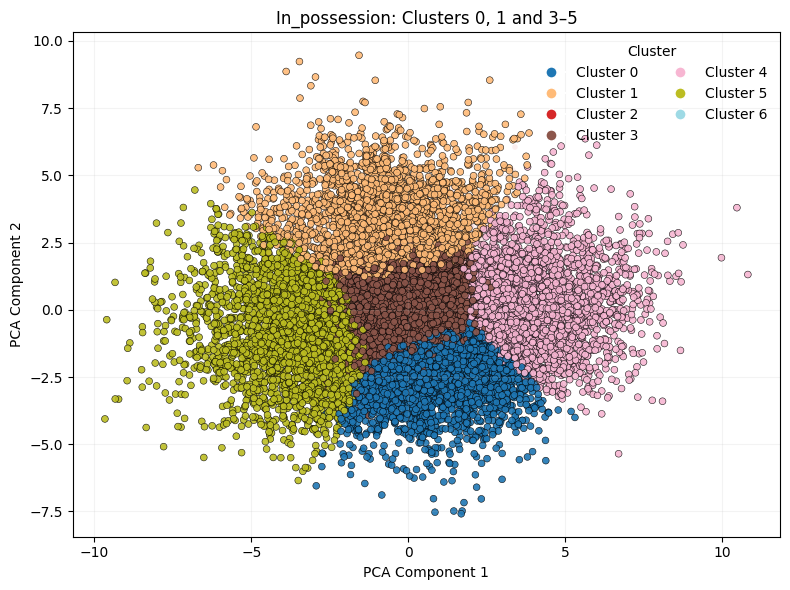

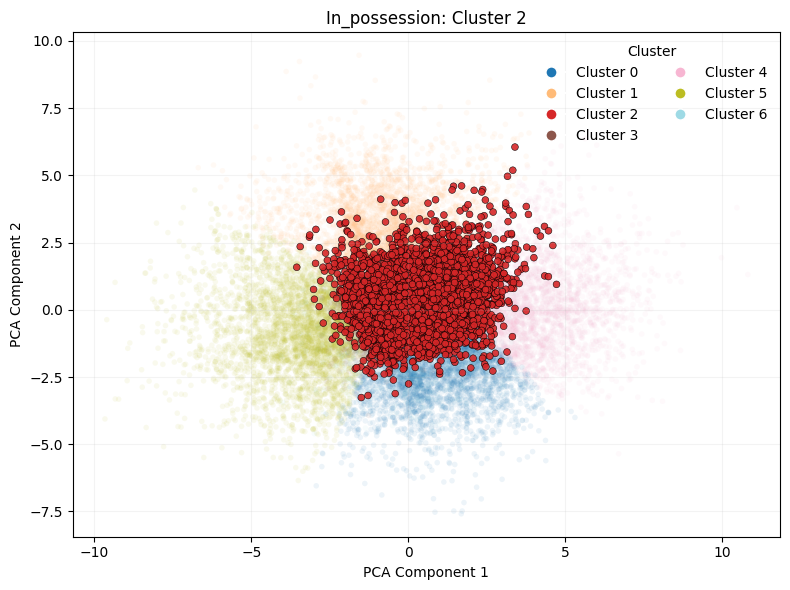

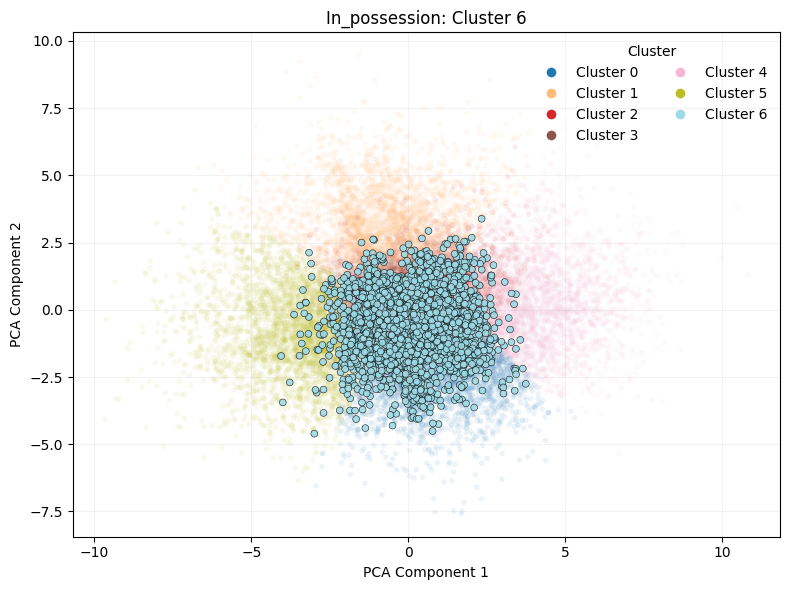

In [ ]:
# PCA on Z_in (latent space)
pca = PCA(n_components=2, random_state=42)
Z_in_2D = pca.fit_transform(Z_in)

# Example: highlight selected clusters
clusters_in = meta_in_k["cluster"].to_numpy()
pca_plot_filter(
    Z_in_2D, clusters_in,
    show=[0,1,3,4,5],
    mode="highlight",
    title="In_possession: Clusters 0, 1 and 3–5"
)

# highlight only cluster 2
pca_plot_filter(
    Z_in_2D, clusters_in,
    show=[2],
    mode="highlight",
    title="In_possession: Cluster 2"
)

# highlight only cluster 6
pca_plot_filter(
    Z_in_2D, clusters_in,
    show=[6],
    mode="highlight",
    title="In_possession: Cluster 6"
)

#### 9. Hierarchical Clustering (Ward) for both

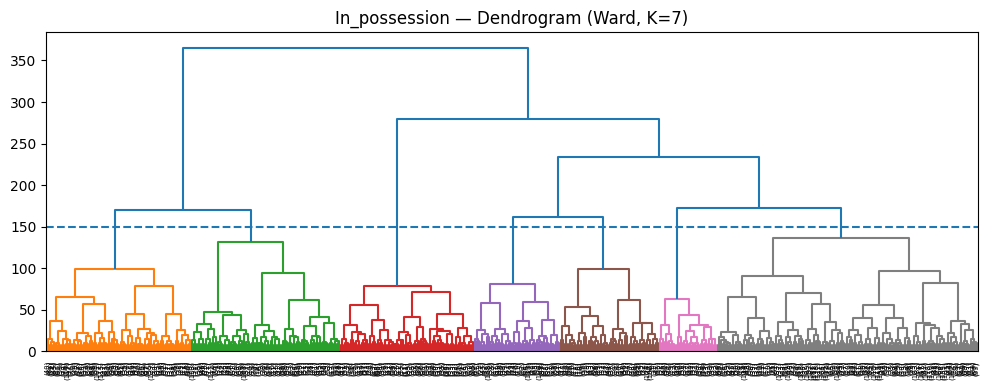

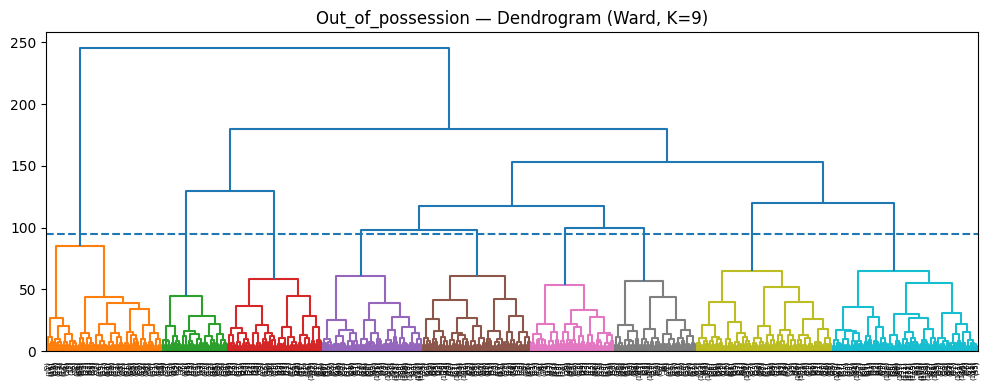

In [19]:
def hierarchical_clustering(Z, meta, K, title_prefix, cut_line=None):
    """
    Perform Ward hierarchical clustering on latent space Z,
    create a dendrogram, and return meta with an additional cluster column.
    """
    Z_link = linkage(Z, method="ward")
    labels = fcluster(Z_link, t=K, criterion="maxclust")

    meta_h = meta.copy()
    meta_h["cluster_h"] = labels

    fig, ax = plt.subplots(figsize=(10, 4))
    dendrogram(
        Z_link, p=500, truncate_mode="lastp",
        show_leaf_counts=True, leaf_rotation=90., ax=ax,
        color_threshold=float(cut_line) if cut_line is not None else None
    )

    # Optional horizontal line at desired height (e.g., 90 or 75)
    if cut_line is not None:
        ax.axhline(y=float(cut_line), linestyle="--", linewidth=1.5)

    ax.set_title(f"{title_prefix} — Dendrogram (Ward, K={K})")
    fig.tight_layout()
    plt.show()

    return meta_h

# Calls with custom cut lines
meta_in_h  = hierarchical_clustering(Z_in,  meta_in,  K=7, title_prefix="In_possession",  cut_line=150)
meta_out_h = hierarchical_clustering(Z_out, meta_out, K=9, title_prefix="Out_of_possession", cut_line=95)

In_possession — Silhouette Score: 0.1963


/tmp/ipykernel_1755965/2326578631.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="count", data=cluster_sizes, palette="tab20")


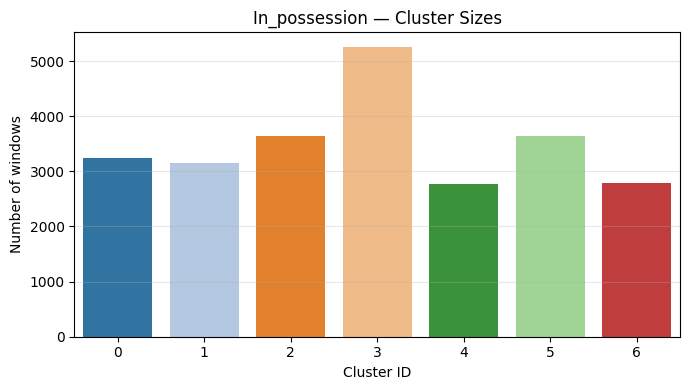

Out_of_possession — Silhouette Score: 0.1986


/tmp/ipykernel_1755965/2326578631.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cluster", y="count", data=cluster_sizes, palette="tab20")


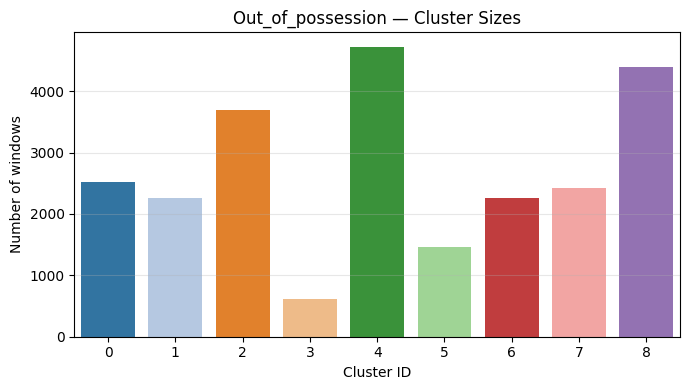

In [23]:
def evaluate_clusters(Z, labels, title_prefix=""):
    """
    Evaluate clusters using:
    - global Silhouette score
    - distribution of cluster sizes (bar plot)
    """
    # 1. Compute Silhouette score
    sil_score = silhouette_score(Z, labels)
    print(f"{title_prefix} — Silhouette Score: {sil_score:.4f}")

    # 2. Compute cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = pd.DataFrame({"cluster": unique, "count": counts})
    
    # 3. Plot cluster size distribution
    plt.figure(figsize=(7,4))
    sns.barplot(x="cluster", y="count", data=cluster_sizes, palette="tab20")
    plt.title(f"{title_prefix} — Cluster Sizes")
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of windows")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return sil_score, cluster_sizes

# For In_possession
sil_in, size_in = evaluate_clusters(Z_in, meta_in_k["cluster"], title_prefix="In_possession")

# For Out_of_possession
sil_out, size_out = evaluate_clusters(Z_out, meta_out_k["cluster"], title_prefix="Out_of_possession")

# 10. Save combined results

In [ ]:
meta_in_h["possession_state"]  = "In_possession"
meta_out_h["possession_state"] = "Out_of_possession"

meta_all = pd.concat([meta_in_h, meta_out_h], ignore_index=True)
meta_all.to_csv("clusters_by_possession.csv", index=False)
print("Saved results to clusters_by_possession.csv")